In [7]:
# 0. Imports & settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from functools import reduce

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)


In [9]:
# 1. Load data

obesity_raw = pd.read_csv("obesity_adults.csv")
health_raw = pd.read_csv("health_nutrition.csv")
pop_raw = pd.read_csv("country_population.csv")

print("Obesity shape:", obesity_raw.shape)
print("Health & nutrition shape:", health_raw.shape)
print("Population shape:", pop_raw.shape)


Obesity shape: (198, 127)
Health & nutrition shape: (23569, 61)
Population shape: (264, 61)


In [10]:
def prepare_obesity(df, start_year=1985, end_year=2015):
    df = df.copy()

    # Rename the country column
    df = df.rename(columns={'Unnamed: 0': 'Country Name'})

    # Drop metadata rows (first 3 rows are description / age / sex headers)
    df = df.iloc[3:].reset_index(drop=True)

    # Keep only columns that are pure years (these correspond to "both sexes")
    year_cols = [c for c in df.columns if c.isdigit()]
    year_cols = [c for c in year_cols if start_year <= int(c) <= end_year]

    cols = ['Country Name'] + sorted(year_cols)
    df = df[cols]

    # Values look like "21.7 [17.0-26.7]" – extract the first numeric part
    for c in year_cols:
        df[c] = (
            df[c]
            .astype(str)
            .str.extract(r'([\d\.]+)', expand=False)
            .astype(float)
        )

    # Wide → long
    long_df = df.melt(
        id_vars='Country Name',
        var_name='Year',
        value_name='Obesity_Adult_BMI30plus'
    )
    long_df['Year'] = long_df['Year'].astype(int)

    return long_df

obesity = prepare_obesity(obesity_raw)
obesity.head()


,Country Name,Year,Obesity_Adult_BMI30plus
0,Afghanistan,1985,1.0
1,Albania,1985,8.5
2,Algeria,1985,10.2
3,Andorra,1985,17.8
4,Angola,1985,1.5


In [11]:
# Indicators we care about (names from the file)
indicator_names = {
    'Life expectancy at birth, total (years)': 'LifeExpectancy',
    'Mortality rate, under-5 (per 1,000)': 'Under5_Mortality',
    'Fertility rate, total (births per woman)': 'FertilityRate',
    'Health expenditure, total (% of GDP)': 'HealthExp_pct_GDP',
    'Health expenditure per capita (current US$)': 'HealthExp_perCapita_USD',
    'GNI per capita, Atlas method (current US$)': 'GNI_perCapita_Atlas_USD'
}

def extract_indicator(df, indicator_name, value_name,
                      start_year=1985, end_year=2015):
    sub = df[df['Indicator Name'] == indicator_name].copy()
    year_cols = [str(y) for y in range(start_year, end_year + 1)]
    cols = ['Country Name', 'Country Code'] + year_cols
    sub = sub[cols]

    long = sub.melt(
        id_vars=['Country Name', 'Country Code'],
        value_vars=year_cols,
        var_name='Year',
        value_name=value_name
    )
    long['Year'] = long['Year'].astype(int)
    return long

health_frames = []

for ind_name, value_name in indicator_names.items():
    health_frames.append(
        extract_indicator(health_raw, ind_name, value_name,
                          start_year=1985, end_year=2015)
    )

# Merge all the indicators on Country + Year
health = reduce(
    lambda left, right: pd.merge(
        left, right,
        on=['Country Name', 'Country Code', 'Year'],
        how='outer'
    ),
    health_frames
)

health.head()


,Country Name,Country Code,Year,LifeExpectancy,Under5_Mortality,FertilityRate,HealthExp_pct_GDP,HealthExp_perCapita_USD,GNI_perCapita_Atlas_USD
0,Afghanistan,AFG,1985,45.577024,216.0,7.458,NaN,NaN,NaN
1,Afghanistan,AFG,1986,46.426951,209.2,7.460,NaN,NaN,NaN
2,Afghanistan,AFG,1987,47.296341,202.1,7.461,NaN,NaN,NaN
3,Afghanistan,AFG,1988,48.169732,195.0,7.461,NaN,NaN,NaN
4,Afghanistan,AFG,1989,49.031122,187.8,7.461,NaN,NaN,NaN


In [12]:
def prepare_population(df, start_year=1985, end_year=2015):
    sub = df[df['Indicator Name'] == 'Population, total'].copy()
    year_cols = [str(y) for y in range(start_year, end_year + 1)]
    cols = ['Country Name', 'Country Code'] + year_cols
    sub = sub[cols]

    long = sub.melt(
        id_vars=['Country Name', 'Country Code'],
        value_vars=year_cols,
        var_name='Year',
        value_name='Population_Total'
    )
    long['Year'] = long['Year'].astype(int)
    return long

population = prepare_population(pop_raw, 1985, 2015)
population.head()


,Country Name,Country Code,Year,Population_Total
0,Aruba,ABW,1985,63026.0
1,Afghanistan,AFG,1985,11783050.0
2,Angola,AGO,1985,10609042.0
3,Albania,ALB,1985,2964762.0
4,Andorra,AND,1985,44600.0


In [13]:
# 2.4 Merge health + population + obesity

data = (
    health
    .merge(population, on=['Country Name', 'Country Code', 'Year'], how='left')
    .merge(obesity, on=['Country Name', 'Year'], how='left')
)

print(data.shape)
data.head()


(2108, 11)


,Country Name,Country Code,Year,LifeExpectancy,Under5_Mortality,FertilityRate,HealthExp_pct_GDP,HealthExp_perCapita_USD,GNI_perCapita_Atlas_USD,Population_Total,Obesity_Adult_BMI30plus
0,Afghanistan,AFG,1985,45.577024,216.0,7.458,NaN,NaN,NaN,11783050.0,1.0
1,Afghanistan,AFG,1986,46.426951,209.2,7.460,NaN,NaN,NaN,11601041.0,1.0
2,Afghanistan,AFG,1987,47.296341,202.1,7.461,NaN,NaN,NaN,11502761.0,1.1
3,Afghanistan,AFG,1988,48.169732,195.0,7.461,NaN,NaN,NaN,11540888.0,1.2
4,Afghanistan,AFG,1989,49.031122,187.8,7.461,NaN,NaN,NaN,11777609.0,1.2


In [14]:
# 3.1 Quick overview
data.info()
data.describe().T.head(15)
# 3.2 Missing values by column
data.isna().mean().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108 entries, 0 to 2107
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country Name             2108 non-null   object 
 1   Country Code             2108 non-null   object 
 2   Year                     2108 non-null   int64  
 3   LifeExpectancy           1966 non-null   float64
 4   Under5_Mortality         2005 non-null   float64
 5   FertilityRate            1971 non-null   float64
 6   HealthExp_pct_GDP        1288 non-null   float64
 7   HealthExp_perCapita_USD  1293 non-null   float64
 8   GNI_perCapita_Atlas_USD  1839 non-null   float64
 9   Population_Total         2077 non-null   float64
 10  Obesity_Adult_BMI30plus  682 non-null    float64
dtypes: float64(8), int64(1), object(2)
memory usage: 181.3+ KB


,0
Obesity_Adult_BMI30plus,0.676471
HealthExp_pct_GDP,0.388994
HealthExp_perCapita_USD,0.386622
GNI_perCapita_Atlas_USD,0.127609
LifeExpectancy,0.067362
FertilityRate,0.064991
Under5_Mortality,0.048861
Population_Total,0.014706
Year,0.000000
Country Name,0.000000


In [15]:
# 3.3 Keep only rows with a target (life expectancy)

model_df = data[~data['LifeExpectancy'].isna()].copy()
print("Rows with life expectancy:", len(model_df))

feature_candidates = [
    'Under5_Mortality',
    'FertilityRate',
    'HealthExp_pct_GDP',
    'HealthExp_perCapita_USD',
    'GNI_perCapita_Atlas_USD',
    'Population_Total',
    'Obesity_Adult_BMI30plus'
]

model_df[feature_candidates].isna().sum()


Rows with life expectancy: 1966


,0
Under5_Mortality,51
FertilityRate,1
HealthExp_pct_GDP,698
HealthExp_perCapita_USD,693
GNI_perCapita_Atlas_USD,228
Population_Total,0
Obesity_Adult_BMI30plus,1336


In [16]:
missing_by_year = (
    data
    .groupby('Year')[feature_candidates + ['LifeExpectancy']]
    .apply(lambda df: df.isna().mean())
)

missing_by_year


,Under5_Mortality,FertilityRate,HealthExp_pct_GDP,HealthExp_perCapita_USD,GNI_perCapita_Atlas_USD,Population_Total,Obesity_Adult_BMI30plus,LifeExpectancy
Year,,,,,,,,
1985,0.073529,0.044118,1.000000,1.000000,0.323529,0.014706,0.676471,0.044118
1986,0.073529,0.044118,1.000000,1.000000,0.308824,0.014706,0.676471,0.044118
1987,0.073529,0.044118,1.000000,1.000000,0.279412,0.014706,0.676471,0.044118
1988,0.073529,0.044118,1.000000,1.000000,0.264706,0.014706,0.676471,0.044118
1989,0.073529,0.044118,1.000000,1.000000,0.264706,0.014706,0.676471,0.044118
1990,0.044118,0.044118,1.000000,1.000000,0.264706,0.014706,0.676471,0.044118
1991,0.044118,0.044118,1.000000,1.000000,0.235294,0.014706,0.676471,0.029412
1992,0.044118,0.044118,1.000000,1.000000,0.191176,0.014706,0.676471,0.044118
1993,0.044118,0.044118,1.000000,1.000000,0.176471,0.014706,0.676471,0.044118


In [17]:
# 4.1 Log transforms for skewed features
for col in ['HealthExp_perCapita_USD',
            'GNI_perCapita_Atlas_USD',
            'Population_Total']:
    model_df[f'log_{col}'] = np.log1p(model_df[col])

feature_cols = [
    'Under5_Mortality',
    'FertilityRate',
    'HealthExp_pct_GDP',
    'HealthExp_perCapita_USD',
    'GNI_perCapita_Atlas_USD',
    'Population_Total',
    'Obesity_Adult_BMI30plus',
    'log_HealthExp_perCapita_USD',
    'log_GNI_perCapita_Atlas_USD',
    'log_Population_Total'
]

target_col = 'LifeExpectancy'


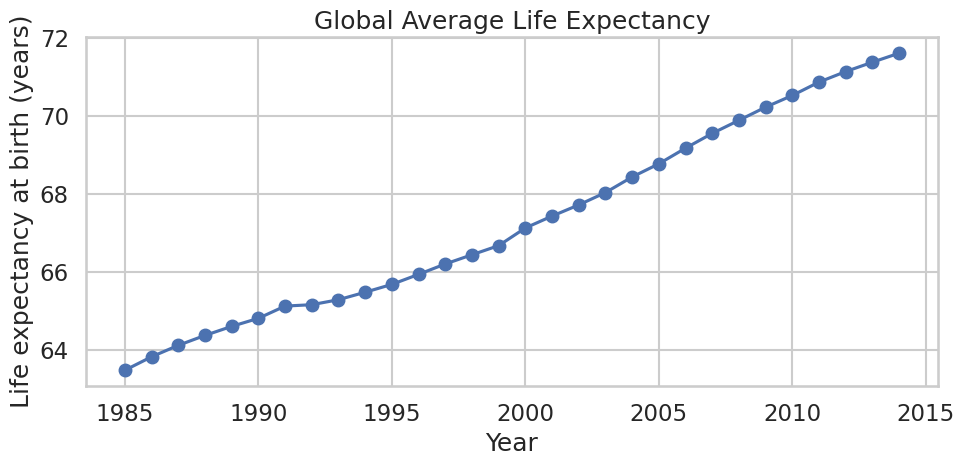

In [18]:
global_trend = (
    model_df
    .groupby('Year')[target_col]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(global_trend['Year'], global_trend[target_col], marker='o')
plt.title("Global Average Life Expectancy")
plt.xlabel("Year")
plt.ylabel("Life expectancy at birth (years)")
plt.tight_layout()
plt.show()


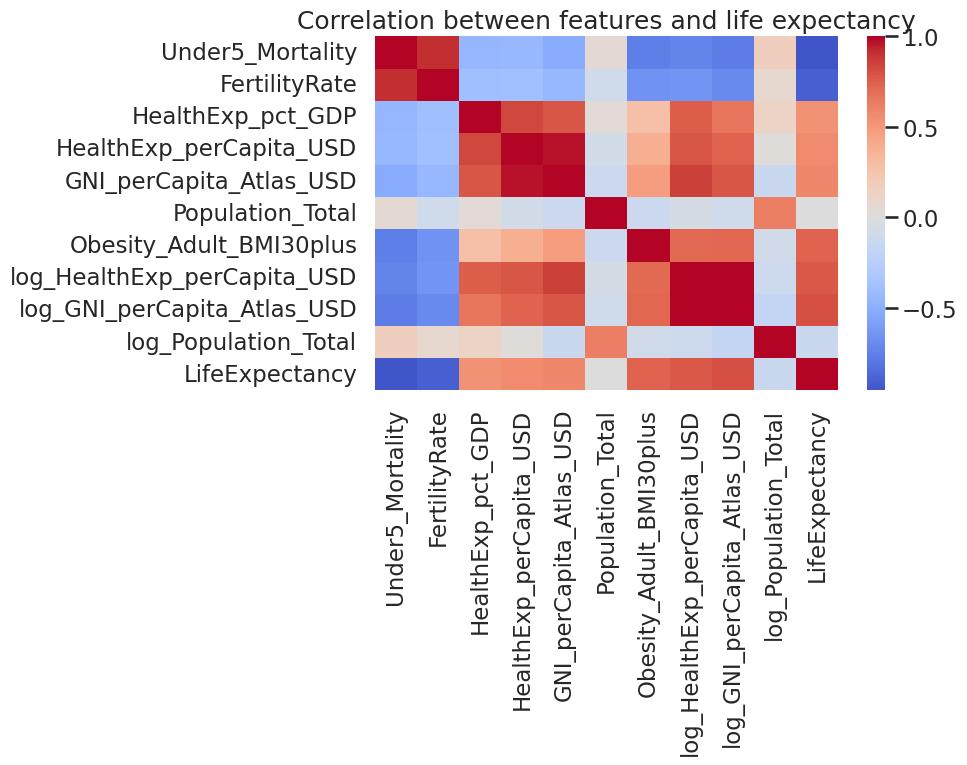

,LifeExpectancy
LifeExpectancy,1.000000
log_GNI_perCapita_Atlas_USD,0.806425
log_HealthExp_perCapita_USD,0.777208
Obesity_Adult_BMI30plus,0.737020
GNI_perCapita_Atlas_USD,0.583267
HealthExp_perCapita_USD,0.564425
HealthExp_pct_GDP,0.527858
Population_Total,0.001735
log_Population_Total,-0.132077
FertilityRate,-0.909917


In [19]:
corr_cols = feature_cols + [target_col]
corr = model_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation between features and life expectancy")
plt.tight_layout()
plt.show()

corr[target_col].sort_values(ascending=False)


Testing randomly

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

numeric_features = feature_cols

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

rf_regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf_regressor)
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print(f"Random Forest – MAE:  {mae:.2f} years")
print(f"Random Forest – RMSE: {rmse:.2f} years")
print(f"Random Forest – R²:   {r2:.3f}")


Random Forest – MAE:  0.43 years
Random Forest – RMSE: 0.76 years
Random Forest – R²:   0.992


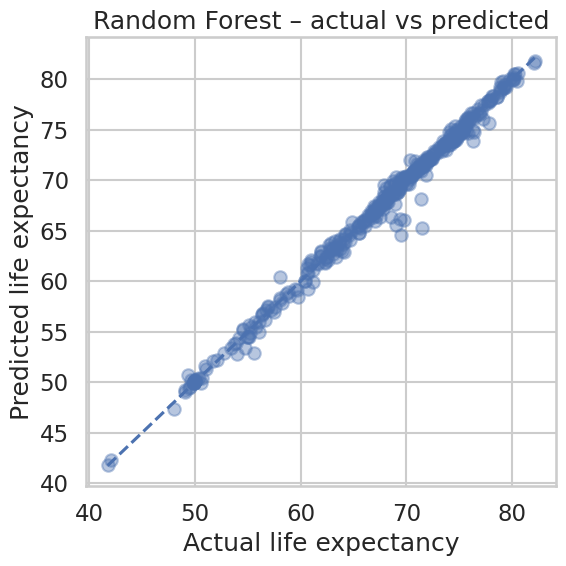

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("Actual life expectancy")
plt.ylabel("Predicted life expectancy")
plt.title("Random Forest – actual vs predicted")
plt.tight_layout()
plt.show()


In [22]:
# Baseline: predict the training mean for everyone
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)

mae_base = mean_absolute_error(y_test, baseline_pred)
mse_base = mean_squared_error(y_test, baseline_pred)
rmse_base = mse_base ** 0.5
r2_base = r2_score(y_test, baseline_pred)

print(f"Baseline (mean) – MAE:  {mae_base:.2f} years")
print(f"Baseline (mean) – RMSE: {rmse_base:.2f} years")
print(f"Baseline (mean) – R²:   {r2_base:.3f}")

print("\nRandom Forest vs Baseline (MAE):")
print(f"RF: {mae:.2f} vs Baseline: {mae_base:.2f}")


Baseline (mean) – MAE:  6.58 years
Baseline (mean) – RMSE: 8.22 years
Baseline (mean) – R²:   -0.001

Random Forest vs Baseline (MAE):
RF: 0.43 vs Baseline: 6.58


In [31]:
rf = rf_model.named_steps["model"]
importances = rf.feature_importances_

feat_importances = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
feat_importances


,0
Under5_Mortality,0.880973
FertilityRate,0.035396
GNI_perCapita_Atlas_USD,0.021993
log_GNI_perCapita_Atlas_USD,0.020022
Population_Total,0.014449
log_Population_Total,0.014150
Obesity_Adult_BMI30plus,0.005839
log_HealthExp_perCapita_USD,0.002881
HealthExp_perCapita_USD,0.002212
HealthExp_pct_GDP,0.002085


Top features: ['Under5_Mortality', 'FertilityRate', 'GNI_perCapita_Atlas_USD', 'log_GNI_perCapita_Atlas_USD']


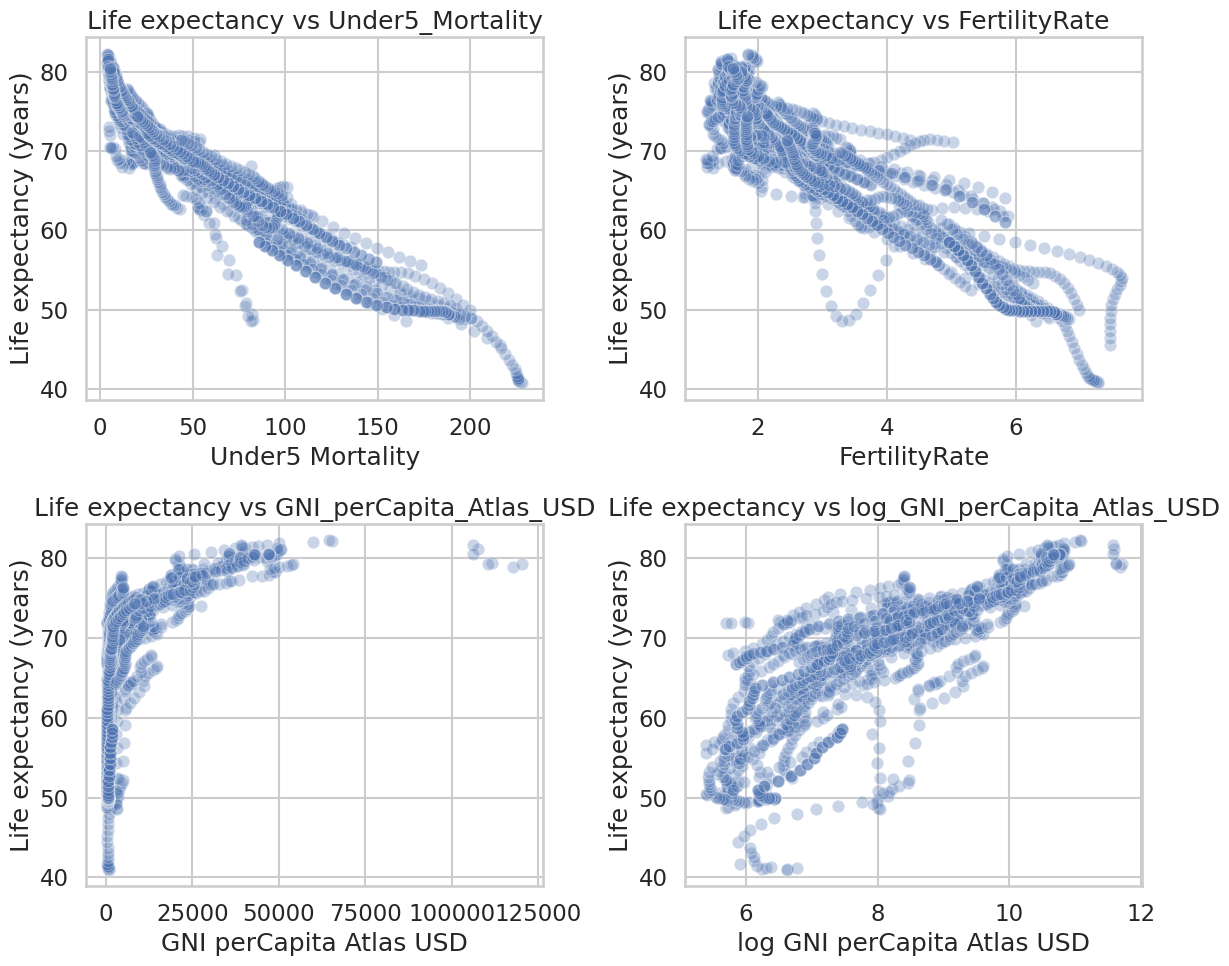

In [36]:
top_features = feat_importances.head(4).index.tolist()
print("Top features:", top_features)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, col in zip(axes, top_features):
    sns.scatterplot(
        data=model_df,
        x=col,
        y='LifeExpectancy',
        alpha=0.3,
        ax=ax
    )
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel("Life expectancy (years)")
    ax.set_title(f"Life expectancy vs {col}")

plt.tight_layout()
plt.show()


Train on <= 2005, test on > 2005

In [23]:
# Time-based split: train on <= 2005, test on > 2005
train_mask = model_df['Year'] <= 2005
test_mask = model_df['Year'] > 2005

X_time_train = model_df.loc[train_mask, feature_cols]
y_time_train = model_df.loc[train_mask, target_col]

X_time_test = model_df.loc[test_mask, feature_cols]
y_time_test = model_df.loc[test_mask, target_col]

print("Time-based split shapes:",
      X_time_train.shape, X_time_test.shape)

rf_time_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf_regressor)
])

rf_time_model.fit(X_time_train, y_time_train)

y_time_pred = rf_time_model.predict(X_time_test)

mae_time = mean_absolute_error(y_time_test, y_time_pred)
mse_time = mean_squared_error(y_time_test, y_time_pred)
rmse_time = mse_time ** 0.5
r2_time = r2_score(y_time_test, y_time_pred)

print(f"Time-based RF – MAE:  {mae_time:.2f}")
print(f"Time-based RF – RMSE: {rmse_time:.2f}")
print(f"Time-based RF – R²:   {r2_time:.3f}")


Time-based split shapes: (1372, 10) (594, 10)
Time-based RF – MAE:  1.41
Time-based RF – RMSE: 2.05
Time-based RF – R²:   0.921


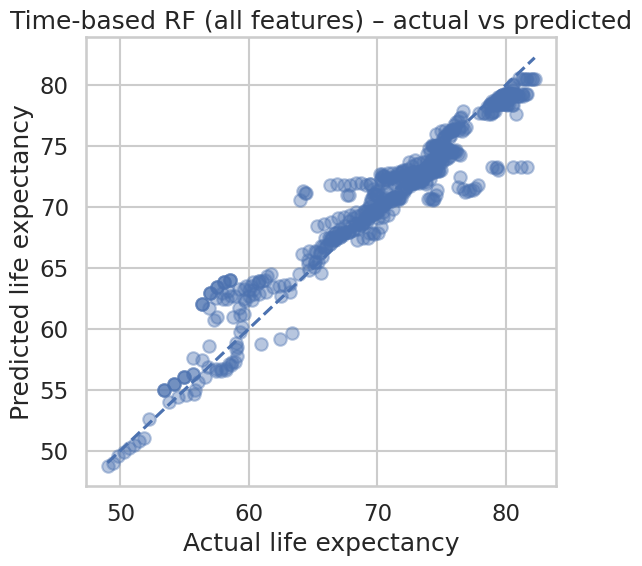

In [44]:
plt.figure(figsize=(6, 6))
plt.scatter(y_time_test, y_time_pred, alpha=0.4)
plt.plot(
    [y_time_test.min(), y_time_test.max()],
    [y_time_test.min(), y_time_test.max()],
    linestyle='--'
)
plt.xlabel("Actual life expectancy")
plt.ylabel("Predicted life expectancy")
plt.title("Time-based RF (all features) – actual vs predicted")
plt.tight_layout()
plt.show()


Now we remove the under-5 mortality feature

In [48]:


# 1. Feature set without Under-5 mortality
feature_cols_no_under5 = [f for f in feature_cols if f != 'Under5_Mortality']
feature_cols_no_under5

# 2. Time-based split: train on <= 2005, test on > 2005
train_mask = model_df['Year'] <= 2005
test_mask  = model_df['Year'] > 2005

X2_time_train = model_df.loc[train_mask, feature_cols_no_under5]
y2_time_train = model_df.loc[train_mask, target_col]

X2_time_test = model_df.loc[test_mask, feature_cols_no_under5]
y2_time_test = model_df.loc[test_mask, target_col]

print("Time-based split shapes (no Under-5):",
      X2_time_train.shape, X2_time_test.shape)

# 3. Preprocessing + RF pipeline (no Under-5)
numeric_features_2 = feature_cols_no_under5

numeric_transformer_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess_2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_2, numeric_features_2)
    ]
)

rf_regressor_2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_time_model_2 = Pipeline(steps=[
    ("preprocess", preprocess_2),
    ("model", rf_regressor_2)
])

# 4. Train on data up to 2005
rf_time_model_2.fit(X2_time_train, y2_time_train)

# 5. Predict on > 2005
y2_time_pred = rf_time_model_2.predict(X2_time_test)

# 6. Metrics
mae2_time = mean_absolute_error(y2_time_test, y2_time_pred)
mse2_time = mean_squared_error(y2_time_test, y2_time_pred)
rmse2_time = mse2_time ** 0.5
r22_time = r2_score(y2_time_test, y2_time_pred)

print(f"Time-based RF (NO Under-5) – MAE:  {mae2_time:.2f}")
print(f"Time-based RF (NO Under-5) – RMSE: {rmse2_time:.2f}")
print(f"Time-based RF (NO Under-5) – R²:   {r22_time:.3f}")


Time-based split shapes (no Under-5): (1372, 9) (594, 9)
Time-based RF (NO Under-5) – MAE:  1.82
Time-based RF (NO Under-5) – RMSE: 2.35
Time-based RF (NO Under-5) – R²:   0.897


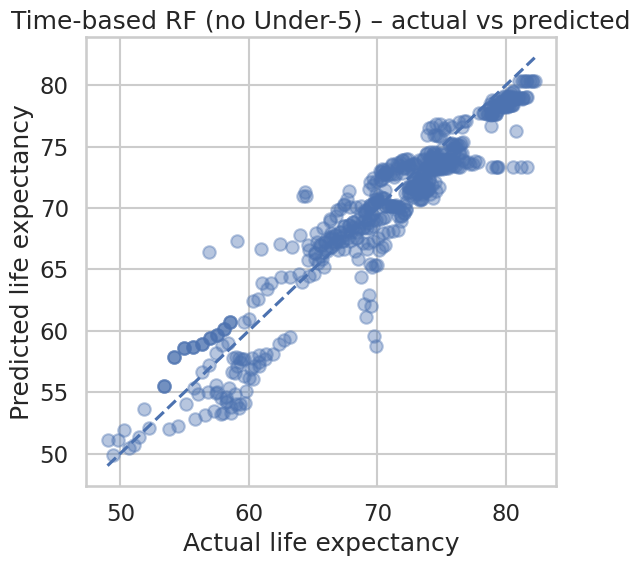

In [49]:
plt.figure(figsize=(6, 6))
plt.scatter(y2_time_test, y2_time_pred, alpha=0.4)
plt.plot(
    [y2_time_test.min(), y2_time_test.max()],
    [y2_time_test.min(), y2_time_test.max()],
    linestyle='--'
)
plt.xlabel("Actual life expectancy")
plt.ylabel("Predicted life expectancy")
plt.title("Time-based RF (no Under-5) – actual vs predicted")
plt.tight_layout()
plt.show()


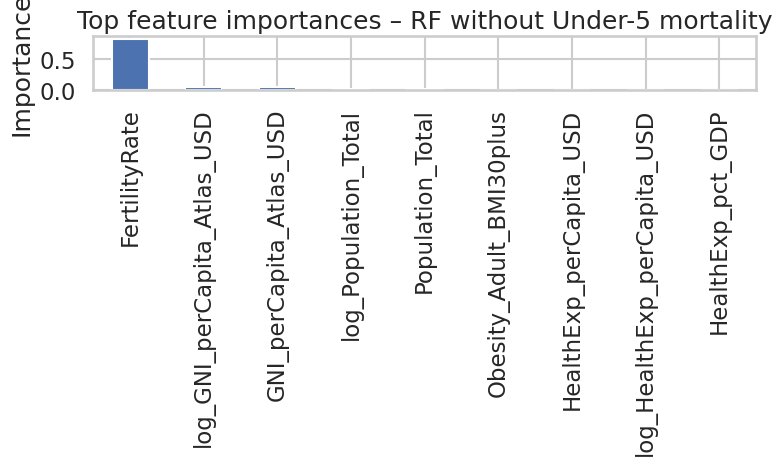

In [51]:
rf2 = rf_time_model_2.named_steps["model"]
importances2 = rf2.feature_importances_

feat_importances2 = pd.Series(importances2, index=feature_cols_no_under5).sort_values(ascending=False)
feat_importances2
plt.figure(figsize=(8, 5))
feat_importances2.head(10).plot(kind='bar')
plt.title("Top feature importances – RF without Under-5 mortality")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


In [52]:
# Take the 4 most important features from the RF without Under-5
top_features = feat_importances2.head(4).index.tolist()
top_features


['FertilityRate',
 'log_GNI_perCapita_Atlas_USD',
 'GNI_perCapita_Atlas_USD',
 'log_Population_Total']

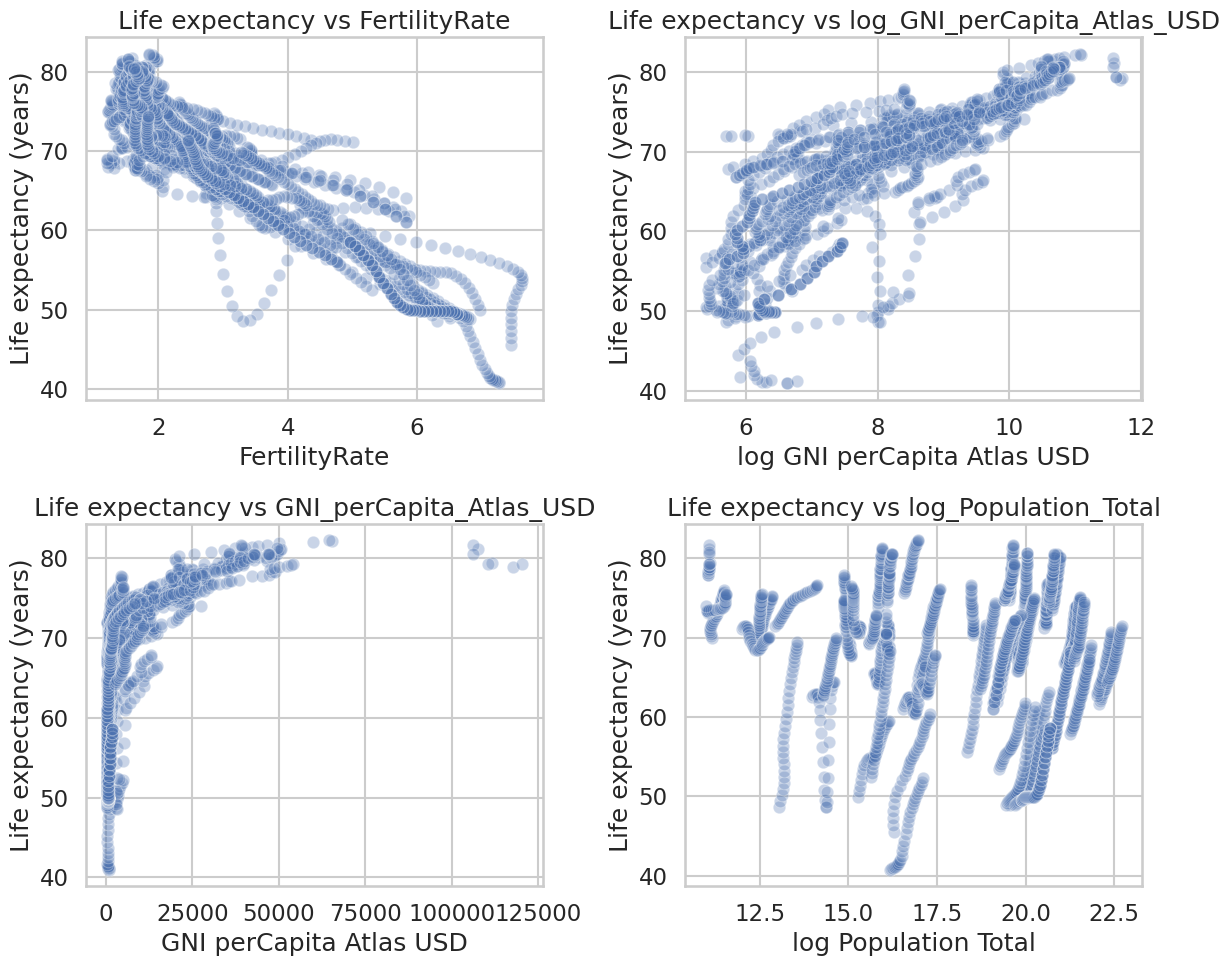

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, col in zip(axes, top_features):
    sns.scatterplot(
        data=model_df,
        x=col,
        y='LifeExpectancy',
        alpha=0.3,
        ax=ax
    )
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel("Life expectancy (years)")
    ax.set_title(f"Life expectancy vs {col}")

plt.tight_layout()
plt.show()


In [54]:
import joblib

# Save the full model (with Under-5 + all other features)
joblib.dump(rf_model, "rf_model_all_features.pkl")

# Also save the feature list used by this model
joblib.dump(feature_cols, "feature_cols_all_features.pkl")

print("Saved rf_model_all_features.pkl and feature_cols_all_features.pkl")


Saved rf_model_all_features.pkl and feature_cols_all_features.pkl
